In [1]:
# ============================================================
# Modeling Part 5 - Final Results, Robustness Checks, and Project Summary
# ============================================================
#
# Goal:
# 1. Load final outputs from Parts 1–4
# 2. Create clean final summary tables
# 3. Create final charts
# 4. Summarize robustness checks
# 5. Save final results for report / README / resume
#
# This notebook does NOT train a new model.
# It organizes and interprets the final results.

import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect()

PROCESSED_DIR = r"data\processed"

# Inputs from earlier notebooks
simple_loose_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_loose.parquet")
simple_strict_file = os.path.join(PROCESSED_DIR, "earnings_model_simple_clean_strict.parquet")

part2_quintile_file = os.path.join(PROCESSED_DIR, "modeling_part2_quintile_results.parquet")
part2_yearly_file = os.path.join(PROCESSED_DIR, "modeling_part2_yearly_quintile_results.parquet")

part3_oos_predictions_file = os.path.join(PROCESSED_DIR, "modeling_part3_oos_predictions.parquet")
part3_oos_quintile_file = os.path.join(PROCESSED_DIR, "modeling_part3_oos_quintile_results.parquet")
part3_model_comparison_csv = os.path.join(PROCESSED_DIR, "modeling_part3_model_comparison.csv")
part3_coef_summary_csv = os.path.join(PROCESSED_DIR, "modeling_part3_coefficient_summary.csv")

part4_strategy_results_file = os.path.join(PROCESSED_DIR, "modeling_part4_strategy_results.parquet")
part4_yearly_results_file = os.path.join(PROCESSED_DIR, "modeling_part4_yearly_strategy_results.parquet")

part4_quintile_perf_csv = os.path.join(PROCESSED_DIR, "modeling_part4_quintile_performance.csv")
part4_model_strategy_comparison_csv = os.path.join(PROCESSED_DIR, "modeling_part4_model_strategy_comparison.csv")
part4_buy_filter_comparison_csv = os.path.join(PROCESSED_DIR, "modeling_part4_buy_filter_comparison.csv")
part4_decile_summary_csv = os.path.join(PROCESSED_DIR, "modeling_part4_decile_summary.csv")

# Outputs from this notebook
final_summary_csv = os.path.join(PROCESSED_DIR, "final_project_summary_table.csv")
final_robustness_csv = os.path.join(PROCESSED_DIR, "final_robustness_summary.csv")
final_resume_bullets_txt = os.path.join(PROCESSED_DIR, "final_resume_bullets.txt")
final_project_summary_txt = os.path.join(PROCESSED_DIR, "final_project_interpretation.txt")

print("Part 5 input files set.")

Part 5 input files set.


In [2]:
# Helper function to display SQL query results neatly

def show(title, query, n=30):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)
    
    df = con.execute(query).df()
    
    if len(df) > n:
        print(df.head(n).to_string(index=False))
        print(f"\n[showing first {n} rows out of {len(df)}]")
    else:
        print(df.to_string(index=False))
    
    return df


# Helper function for percentage formatting

def as_pct(x):
    if pd.isna(x):
        return ""
    return f"{100 * x:.2f}%"


# Helper function to check file existence

def check_file(path):
    if not os.path.exists(path):
        print(f"Missing: {path}")
        return False
    return True

In [3]:
# Check which files are available.
#
# If a file is missing, it usually means the corresponding earlier notebook
# was not run or the output filename is different.

required_files = [
    simple_loose_file,
    simple_strict_file,
    part3_oos_predictions_file,
    part4_strategy_results_file,
    part4_yearly_results_file,
    part4_model_strategy_comparison_csv,
    part4_buy_filter_comparison_csv,
    part4_decile_summary_csv,
]

optional_files = [
    part2_quintile_file,
    part2_yearly_file,
    part3_oos_quintile_file,
    part3_model_comparison_csv,
    part3_coef_summary_csv,
    part4_quintile_perf_csv,
]

print("Required files:")
all_required_exist = True
for f in required_files:
    exists = check_file(f)
    all_required_exist = all_required_exist and exists
    print(exists, f)

print("\nOptional files:")
for f in optional_files:
    print(check_file(f), f)

if not all_required_exist:
    raise FileNotFoundError("One or more required files are missing. Run Parts 1–4 first.")

print("\nAll required files found.")

Required files:
True data\processed\earnings_model_simple_clean_loose.parquet
True data\processed\earnings_model_simple_clean_strict.parquet
True data\processed\modeling_part3_oos_predictions.parquet
True data\processed\modeling_part4_strategy_results.parquet
True data\processed\modeling_part4_yearly_strategy_results.parquet
True data\processed\modeling_part4_model_strategy_comparison.csv
True data\processed\modeling_part4_buy_filter_comparison.csv
True data\processed\modeling_part4_decile_summary.csv

Optional files:
True data\processed\modeling_part2_quintile_results.parquet
True data\processed\modeling_part2_yearly_quintile_results.parquet
True data\processed\modeling_part3_oos_quintile_results.parquet
Missing: data\processed\modeling_part3_model_comparison.csv
False data\processed\modeling_part3_model_comparison.csv
Missing: data\processed\modeling_part3_coefficient_summary.csv
False data\processed\modeling_part3_coefficient_summary.csv
True data\processed\modeling_part4_quintile_p

In [4]:
# Load core datasets into DuckDB.
#
# loose and strict:
#     final clean datasets from Part 1
#
# oos_predictions:
#     out-of-sample model predictions from Part 3
#
# strategy_results:
#     strategy summary from Part 4
#
# yearly_strategy:
#     yearly strategy results from Part 4

con.execute(f"""
CREATE OR REPLACE TEMP TABLE simple_loose AS
SELECT *
FROM read_parquet('{simple_loose_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE simple_strict AS
SELECT *
FROM read_parquet('{simple_strict_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE oos_predictions AS
SELECT *
FROM read_parquet('{part3_oos_predictions_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE strategy_results AS
SELECT *
FROM read_parquet('{part4_strategy_results_file}')
""")

con.execute(f"""
CREATE OR REPLACE TEMP TABLE yearly_strategy AS
SELECT *
FROM read_parquet('{part4_yearly_results_file}')
""")

show(
    "Loaded dataset row counts",
    """
    SELECT 'simple_loose' AS dataset, COUNT(*) AS n_rows FROM simple_loose
    UNION ALL
    SELECT 'simple_strict' AS dataset, COUNT(*) AS n_rows FROM simple_strict
    UNION ALL
    SELECT 'oos_predictions' AS dataset, COUNT(*) AS n_rows FROM oos_predictions
    UNION ALL
    SELECT 'strategy_results' AS dataset, COUNT(*) AS n_rows FROM strategy_results
    UNION ALL
    SELECT 'yearly_strategy' AS dataset, COUNT(*) AS n_rows FROM yearly_strategy
    """
)


Loaded dataset row counts
         dataset  n_rows
    simple_loose    9022
   simple_strict    7412
 oos_predictions   11032
strategy_results      16
 yearly_strategy       8


,dataset,n_rows
0,simple_loose,9022
1,simple_strict,7412
2,oos_predictions,11032
3,strategy_results,16
4,yearly_strategy,8


In [5]:
# Load CSV summary files created in Parts 3 and 4.
#
# These files are easier to use for final summary tables.

model_strategy_comparison = pd.read_csv(part4_model_strategy_comparison_csv)
buy_filter_comparison = pd.read_csv(part4_buy_filter_comparison_csv)
decile_summary = pd.read_csv(part4_decile_summary_csv)

if os.path.exists(part3_coef_summary_csv):
    coef_summary = pd.read_csv(part3_coef_summary_csv)
else:
    coef_summary = pd.DataFrame()

if os.path.exists(part3_model_comparison_csv):
    part3_model_comparison = pd.read_csv(part3_model_comparison_csv)
else:
    part3_model_comparison = pd.DataFrame()

print("model_strategy_comparison:")
display(model_strategy_comparison)

print("buy_filter_comparison:")
display(buy_filter_comparison)

print("decile_summary:")
display(decile_summary)

if len(coef_summary) > 0:
    print("coef_summary:")
    display(coef_summary)

model_strategy_comparison:


,model,n_total_events,n_q1,n_q5,buy_all_mid_edge,buy_q5_mid_edge,buy_q5_ask_edge,buy_q1_mid_edge,short_q1_bid_edge,q5_minus_q1_mid_edge,long_q5_ask_short_q1_bid_edge,q5_pct_positive_mid_edge,q5_pct_positive_ask_edge,q1_pct_positive_short_bid_edge
0,linear_regression,5516,1105,1104,-0.0136,-0.004806,-0.006032,-0.024319,0.018946,0.019513,0.012914,0.35779,0.336957,0.718552
1,ridge_regression,5516,1105,1104,-0.0136,-0.004806,-0.006032,-0.024319,0.018946,0.019513,0.012914,0.35779,0.336957,0.718552


buy_filter_comparison:


,model,buy_all_mid_edge,buy_q5_mid_edge,buy_q5_ask_edge,q5_pct_positive_mid_edge,q5_pct_positive_ask_edge,q5_improvement_vs_all_mid
0,linear_regression,-0.0136,-0.004806,-0.006032,0.35779,0.336957,0.008794
1,ridge_regression,-0.0136,-0.004806,-0.006032,0.35779,0.336957,0.008794


decile_summary:


,model,d1_mid_edge,d10_mid_edge,d10_minus_d1_mid_edge,d10_long_ask_edge,d1_short_bid_edge,long_d10_ask_short_d1_bid_edge,n_d1,n_d10
0,linear_regression,-0.030763,-0.003288,0.027476,-0.004285,0.024948,0.020663,553,553
1,ridge_regression,-0.030763,-0.003288,0.027476,-0.004285,0.024948,0.020663,553,553


In [6]:
# Summarize the final clean datasets.
#
# This table answers:
#     How many events?
#     How many tickers?
#     What is the average implied move?
#     What is the average realized move?
#     What is the average edge?

baseline_summary = show(
    "Final clean dataset summary",
    """
    SELECT
        'loose' AS dataset,
        COUNT(*) AS n_events,
        COUNT(DISTINCT tic) AS n_tickers,
        MIN(rdq) AS start_date,
        MAX(rdq) AS end_date,
        AVG(implied_move_simple) AS avg_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(simple_straddle_edge_open) AS avg_edge,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.50) AS median_edge
    FROM simple_loose

    UNION ALL

    SELECT
        'strict' AS dataset,
        COUNT(*) AS n_events,
        COUNT(DISTINCT tic) AS n_tickers,
        MIN(rdq) AS start_date,
        MAX(rdq) AS end_date,
        AVG(implied_move_simple) AS avg_implied_move,
        AVG(realized_move_open_to_prevclose) AS avg_realized_move,
        AVG(simple_straddle_edge_open) AS avg_edge,
        APPROX_QUANTILE(simple_straddle_edge_open, 0.50) AS median_edge
    FROM simple_strict
    """
)

# Add percentage-formatted columns for easier reading
baseline_summary_display = baseline_summary.copy()

for col in ["avg_implied_move", "avg_realized_move", "avg_edge", "median_edge"]:
    baseline_summary_display[col + "_pct"] = baseline_summary_display[col].apply(as_pct)

display(baseline_summary_display)


Final clean dataset summary
dataset  n_events  n_tickers start_date   end_date  avg_implied_move  avg_realized_move  avg_edge  median_edge
  loose      9022        474 2018-02-08 2024-12-20          0.057131           0.042723 -0.014408    -0.019029
 strict      7412        457 2018-02-08 2024-12-20          0.057282           0.043692 -0.013590    -0.017661


,dataset,n_events,n_tickers,start_date,end_date,avg_implied_move,avg_realized_move,avg_edge,median_edge,avg_implied_move_pct,avg_realized_move_pct,avg_edge_pct,median_edge_pct
0,loose,9022,474,2018-02-08,2024-12-20,0.057131,0.042723,-0.014408,-0.019029,5.71%,4.27%,-1.44%,-1.90%
1,strict,7412,457,2018-02-08,2024-12-20,0.057282,0.043692,-0.013590,-0.017661,5.73%,4.37%,-1.36%,-1.77%


In [7]:
# Part 2 showed that implied move was the strongest simple single-variable signal.
#
# If the Part 2 quintile file exists, summarize the Q5 - Q1 spread
# for each signal.

if os.path.exists(part2_quintile_file):
    con.execute(f"""
    CREATE OR REPLACE TEMP TABLE part2_quintiles AS
    SELECT *
    FROM read_parquet('{part2_quintile_file}')
    """)

    part2_signal_summary = show(
        "Part 2 signal Q5 - Q1 summary",
        """
        WITH q AS (
            SELECT
                dataset,
                signal,
                MAX(CASE WHEN quintile = 1 THEN avg_edge END) AS q1_edge,
                MAX(CASE WHEN quintile = 5 THEN avg_edge END) AS q5_edge
            FROM part2_quintiles
            GROUP BY dataset, signal
        )
        SELECT
            dataset,
            signal,
            q1_edge,
            q5_edge,
            q5_edge - q1_edge AS q5_minus_q1_edge
        FROM q
        ORDER BY dataset, q5_minus_q1_edge
        """
    )
    
    part2_signal_summary_display = part2_signal_summary.copy()
    for col in ["q1_edge", "q5_edge", "q5_minus_q1_edge"]:
        part2_signal_summary_display[col + "_pct"] = part2_signal_summary_display[col].apply(as_pct)
    
    display(part2_signal_summary_display)
else:
    print("Part 2 quintile file not found. Skipping this cell.")


Part 2 signal Q5 - Q1 summary
dataset                  signal   q1_edge   q5_edge  q5_minus_q1_edge
  loose     implied_move_simple -0.005567 -0.025384         -0.019817
  loose        total_spread_pct -0.011134 -0.019076         -0.007942
  loose log_total_open_interest -0.014147 -0.015383         -0.001236
  loose                om_close -0.017863 -0.012090          0.005773
  loose        log_total_volume -0.020498 -0.010727          0.009770
 strict     implied_move_simple -0.005031 -0.024635         -0.019604
 strict        total_spread_pct -0.010436 -0.018283         -0.007847
 strict log_total_open_interest -0.013143 -0.014563         -0.001420
 strict                om_close -0.017673 -0.011379          0.006294
 strict        log_total_volume -0.019130 -0.010834          0.008295


,dataset,signal,q1_edge,q5_edge,q5_minus_q1_edge,q1_edge_pct,q5_edge_pct,q5_minus_q1_edge_pct
0,loose,implied_move_simple,-0.005567,-0.025384,-0.019817,-0.56%,-2.54%,-1.98%
1,loose,total_spread_pct,-0.011134,-0.019076,-0.007942,-1.11%,-1.91%,-0.79%
2,loose,log_total_open_interest,-0.014147,-0.015383,-0.001236,-1.41%,-1.54%,-0.12%
3,loose,om_close,-0.017863,-0.012090,0.005773,-1.79%,-1.21%,0.58%
4,loose,log_total_volume,-0.020498,-0.010727,0.009770,-2.05%,-1.07%,0.98%
5,strict,implied_move_simple,-0.005031,-0.024635,-0.019604,-0.50%,-2.46%,-1.96%
6,strict,total_spread_pct,-0.010436,-0.018283,-0.007847,-1.04%,-1.83%,-0.78%
7,strict,log_total_open_interest,-0.013143,-0.014563,-0.001420,-1.31%,-1.46%,-0.14%
8,strict,om_close,-0.017673,-0.011379,0.006294,-1.77%,-1.14%,0.63%
9,strict,log_total_volume,-0.019130,-0.010834,0.008295,-1.91%,-1.08%,0.83%


In [8]:
# Part 3 compared:
#     baseline_negative_implied_move
#     linear_regression
#     ridge_regression
#
# The key metric:
#     Q5 - Q1 actual edge
#
# For predicted-edge models:
#     Q1 = predicted-worst
#     Q5 = predicted-best
#
# Positive Q5 - Q1 means the model ranks correctly.

if len(part3_model_comparison) > 0:
    part3_model_display = part3_model_comparison.copy()
    
    for col in part3_model_display.columns:
        if "edge" in col:
            part3_model_display[col + "_pct"] = part3_model_display[col].apply(as_pct)
    
    print("Part 3 model comparison:")
    display(part3_model_display)
else:
    print("Part 3 model comparison CSV not found.")

Part 3 model comparison CSV not found.


In [9]:
# Summarize Part 4 strategy results.
#
# These are the most important economic interpretation results.

strategy_summary = con.execute("""
SELECT *
FROM strategy_results
ORDER BY model, strategy
""").df()

strategy_summary_display = strategy_summary.copy()

for col in ["avg_edge", "median_edge", "pct_positive"]:
    if col in strategy_summary_display.columns:
        if col == "pct_positive":
            strategy_summary_display[col + "_pct"] = strategy_summary_display[col].apply(as_pct)
        else:
            strategy_summary_display[col + "_pct"] = strategy_summary_display[col].apply(as_pct)

display(strategy_summary_display)

,model,strategy,n_events,avg_edge,median_edge,pct_positive,avg_edge_pct,median_edge_pct,pct_positive_pct
0,linear_regression,Buy Q1 predicted-worst - midpoint,1105,-0.024319,-0.036882,0.250679,-2.43%,-3.69%,25.07%
1,linear_regression,Buy Q5 predicted-best - at ask,1104,-0.006032,-0.010288,0.336957,-0.60%,-1.03%,33.70%
2,linear_regression,Buy Q5 predicted-best - midpoint,1104,-0.004806,-0.009156,0.357790,-0.48%,-0.92%,35.78%
3,linear_regression,Buy all straddles - at ask,5516,-0.016555,-0.021338,0.267585,-1.66%,-2.13%,26.76%
4,linear_regression,Buy all straddles - midpoint,5516,-0.013600,-0.018729,0.290790,-1.36%,-1.87%,29.08%
5,linear_regression,Long Q5 / Short Q1 - midpoint spread,1104,0.019513,0.027726,NaN,1.95%,2.77%,
6,linear_regression,Long Q5 at ask / Short Q1 at bid,1104,0.012914,0.019943,NaN,1.29%,1.99%,
7,linear_regression,Short Q1 predicted-worst - at bid,1105,0.018946,0.030231,0.718552,1.89%,3.02%,71.86%
8,ridge_regression,Buy Q1 predicted-worst - midpoint,1105,-0.024319,-0.036882,0.250679,-2.43%,-3.69%,25.07%
9,ridge_regression,Buy Q5 predicted-best - at ask,1104,-0.006032,-0.010288,0.336957,-0.60%,-1.03%,33.70%


In [10]:
# Build a compact final headline table for the project.
#
# This table contains the main numbers you would mention in a report/interview.

# Use linear_regression as the primary model because linear and ridge are nearly identical.
primary_model = "linear_regression"

model_row = model_strategy_comparison[
    model_strategy_comparison["model"] == primary_model
].iloc[0]

decile_row = decile_summary[
    decile_summary["model"] == primary_model
].iloc[0]

loose_baseline = baseline_summary[
    baseline_summary["dataset"] == "loose"
].iloc[0]

headline_rows = [
    {
        "result": "Loose clean sample events",
        "value": loose_baseline["n_events"],
        "interpretation": "Number of earnings events in the main clean dataset"
    },
    {
        "result": "Loose clean sample tickers",
        "value": loose_baseline["n_tickers"],
        "interpretation": "Number of unique tickers in the main clean dataset"
    },
    {
        "result": "Average implied move",
        "value": loose_baseline["avg_implied_move"],
        "interpretation": "Average move priced by the pre-earnings ATM straddle"
    },
    {
        "result": "Average realized move",
        "value": loose_baseline["avg_realized_move"],
        "interpretation": "Average actual post-earnings move"
    },
    {
        "result": "Average straddle edge",
        "value": loose_baseline["avg_edge"],
        "interpretation": "Realized move minus implied move; negative means straddles expensive on average"
    },
    {
        "result": "Buy all straddles midpoint edge",
        "value": model_row["buy_all_mid_edge"],
        "interpretation": "Average edge from buying all test-period straddles at midpoint"
    },
    {
        "result": "Buy Q5 predicted-best midpoint edge",
        "value": model_row["buy_q5_mid_edge"],
        "interpretation": "Average edge from buying only model's top quintile at midpoint"
    },
    {
        "result": "Buy Q5 predicted-best ask edge",
        "value": model_row["buy_q5_ask_edge"],
        "interpretation": "Average edge from buying model's top quintile at ask"
    },
    {
        "result": "Q5 - Q1 midpoint spread",
        "value": model_row["q5_minus_q1_mid_edge"],
        "interpretation": "Predicted-best minus predicted-worst midpoint edge"
    },
    {
        "result": "Q5 ask / Q1 bid spread",
        "value": model_row["long_q5_ask_short_q1_bid_edge"],
        "interpretation": "Long top quintile at ask and short bottom quintile at bid"
    },
    {
        "result": "D10 - D1 midpoint spread",
        "value": decile_row["d10_minus_d1_mid_edge"],
        "interpretation": "Top decile minus bottom decile midpoint edge"
    },
    {
        "result": "D10 ask / D1 bid spread",
        "value": decile_row["long_d10_ask_short_d1_bid_edge"],
        "interpretation": "Long top decile at ask and short bottom decile at bid"
    }
]

headline_summary = pd.DataFrame(headline_rows)

# Add readable formatted value
def format_headline_value(row):
    if "events" in row["result"].lower() or "tickers" in row["result"].lower():
        return f"{int(row['value']):,}"
    return as_pct(row["value"])

headline_summary["formatted_value"] = headline_summary.apply(format_headline_value, axis=1)

display(headline_summary)

headline_summary.to_csv(final_summary_csv, index=False)

print("Saved final summary table to:")
print(final_summary_csv)

,result,value,interpretation,formatted_value
0,Loose clean sample events,9022.000000,Number of earnings events in the main clean da...,"9,022"
1,Loose clean sample tickers,474.000000,Number of unique tickers in the main clean dat...,474
2,Average implied move,0.057131,Average move priced by the pre-earnings ATM st...,5.71%
3,Average realized move,0.042723,Average actual post-earnings move,4.27%
4,Average straddle edge,-0.014408,Realized move minus implied move; negative mea...,-1.44%
5,Buy all straddles midpoint edge,-0.013600,Average edge from buying all test-period strad...,-1.36%
6,Buy Q5 predicted-best midpoint edge,-0.004806,Average edge from buying only model's top quin...,-0.48%
7,Buy Q5 predicted-best ask edge,-0.006032,Average edge from buying model's top quintile ...,-0.60%
8,Q5 - Q1 midpoint spread,0.019513,Predicted-best minus predicted-worst midpoint ...,1.95%
9,Q5 ask / Q1 bid spread,0.012914,Long top quintile at ask and short bottom quin...,1.29%


Saved final summary table to:
data\processed\final_project_summary_table.csv


In [11]:
# Create a robustness summary.
#
# This table says whether the main result survives different checks:
#     loose vs strict
#     linear vs ridge
#     midpoint vs bid/ask
#     quintile vs decile
#     year-by-year

yearly_strategy = con.execute("""
SELECT *
FROM yearly_strategy
""").df()

primary_yearly = yearly_strategy[
    yearly_strategy["model"] == primary_model
].copy()

robustness_rows = []

# Loose vs strict from Part 1
strict_baseline = baseline_summary[
    baseline_summary["dataset"] == "strict"
].iloc[0]

robustness_rows.append({
    "check": "Loose vs strict dataset",
    "result": "Stable average edge",
    "evidence": (
        f"Loose avg edge {as_pct(loose_baseline['avg_edge'])}; "
        f"strict avg edge {as_pct(strict_baseline['avg_edge'])}"
    )
})

# Linear vs ridge
ridge_row = model_strategy_comparison[
    model_strategy_comparison["model"] == "ridge_regression"
].iloc[0]

robustness_rows.append({
    "check": "Linear vs ridge",
    "result": "Nearly identical",
    "evidence": (
        f"Linear Q5-Q1 midpoint {as_pct(model_row['q5_minus_q1_mid_edge'])}; "
        f"ridge Q5-Q1 midpoint {as_pct(ridge_row['q5_minus_q1_mid_edge'])}"
    )
})

# Midpoint vs bid/ask
robustness_rows.append({
    "check": "Midpoint vs bid/ask transaction cost",
    "result": "Spread remains positive",
    "evidence": (
        f"Midpoint Q5-Q1 {as_pct(model_row['q5_minus_q1_mid_edge'])}; "
        f"ask/bid spread {as_pct(model_row['long_q5_ask_short_q1_bid_edge'])}"
    )
})

# Quintile vs decile
robustness_rows.append({
    "check": "Quintile vs decile",
    "result": "Signal stronger in extremes",
    "evidence": (
        f"Q5-Q1 midpoint {as_pct(model_row['q5_minus_q1_mid_edge'])}; "
        f"D10-D1 midpoint {as_pct(decile_row['d10_minus_d1_mid_edge'])}"
    )
})

# Year-by-year stability
n_years = len(primary_yearly)
n_positive_mid = (primary_yearly["q5_minus_q1_mid_edge"] > 0).sum()
n_positive_cost = (primary_yearly["long_q5_ask_short_q1_bid_edge"] > 0).sum()

robustness_rows.append({
    "check": "Year-by-year midpoint spread",
    "result": f"Positive in {n_positive_mid}/{n_years} years",
    "evidence": ", ".join(
        [
            f"{int(row['test_year'])}: {as_pct(row['q5_minus_q1_mid_edge'])}"
            for _, row in primary_yearly.iterrows()
        ]
    )
})

robustness_rows.append({
    "check": "Year-by-year bid/ask spread",
    "result": f"Positive in {n_positive_cost}/{n_years} years",
    "evidence": ", ".join(
        [
            f"{int(row['test_year'])}: {as_pct(row['long_q5_ask_short_q1_bid_edge'])}"
            for _, row in primary_yearly.iterrows()
        ]
    )
})

robustness_summary = pd.DataFrame(robustness_rows)

display(robustness_summary)

robustness_summary.to_csv(final_robustness_csv, index=False)

print("Saved robustness summary to:")
print(final_robustness_csv)

,check,result,evidence
0,Loose vs strict dataset,Stable average edge,Loose avg edge -1.44%; strict avg edge -1.36%
1,Linear vs ridge,Nearly identical,Linear Q5-Q1 midpoint 1.95%; ridge Q5-Q1 midpo...
2,Midpoint vs bid/ask transaction cost,Spread remains positive,Midpoint Q5-Q1 1.95%; ask/bid spread 1.29%
3,Quintile vs decile,Signal stronger in extremes,Q5-Q1 midpoint 1.95%; D10-D1 midpoint 2.75%
4,Year-by-year midpoint spread,Positive in 4/4 years,"2021: 2.38%, 2022: 3.02%, 2023: 1.29%, 2024: 1..."
5,Year-by-year bid/ask spread,Positive in 4/4 years,"2021: 1.61%, 2022: 2.16%, 2023: 0.79%, 2024: 0..."


Saved robustness summary to:
data\processed\final_robustness_summary.csv


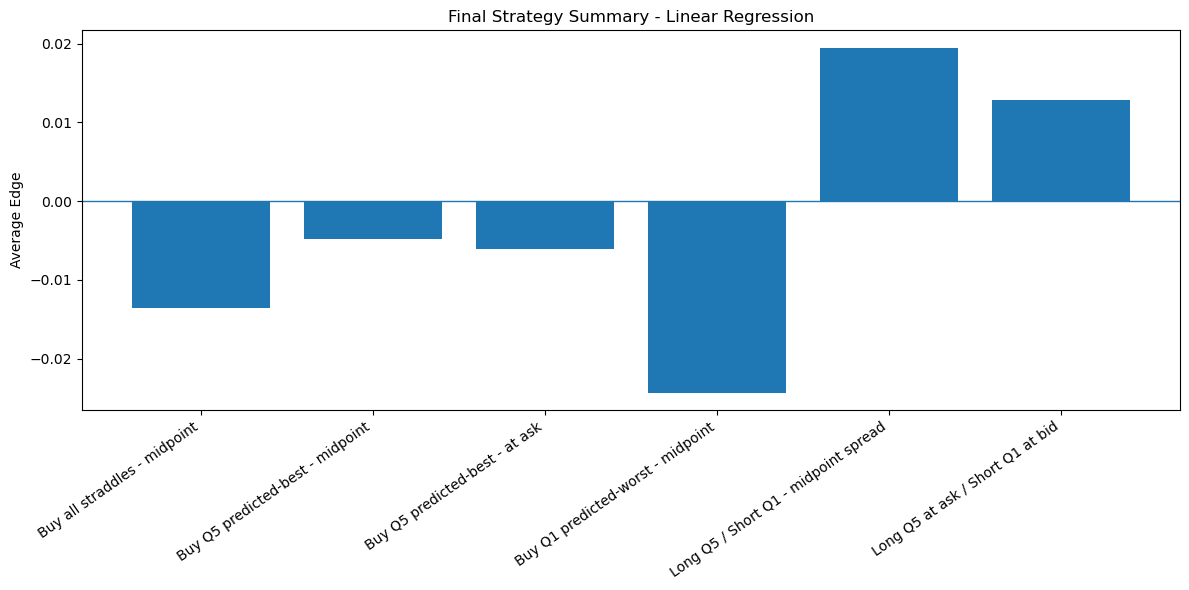

In [12]:
# Final chart 1:
# Compare key strategy edges for the primary model.
#
# This chart shows:
#     buying all straddles is bad
#     buying Q5 is better but still negative
#     buying Q1 is much worse
#     long Q5 / short Q1 spread is positive

plot_strategies = [
    "Buy all straddles - midpoint",
    "Buy Q5 predicted-best - midpoint",
    "Buy Q5 predicted-best - at ask",
    "Buy Q1 predicted-worst - midpoint",
    "Long Q5 / Short Q1 - midpoint spread",
    "Long Q5 at ask / Short Q1 at bid"
]

plot_df = strategy_summary[
    (strategy_summary["model"] == primary_model) &
    (strategy_summary["strategy"].isin(plot_strategies))
].copy()

# Preserve order
plot_df["strategy"] = pd.Categorical(
    plot_df["strategy"],
    categories=plot_strategies,
    ordered=True
)

plot_df = plot_df.sort_values("strategy")

plt.figure(figsize=(12, 6))
plt.bar(plot_df["strategy"], plot_df["avg_edge"])
plt.axhline(0, linewidth=1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Average Edge")
plt.title("Final Strategy Summary - Linear Regression")
plt.tight_layout()
plt.show()

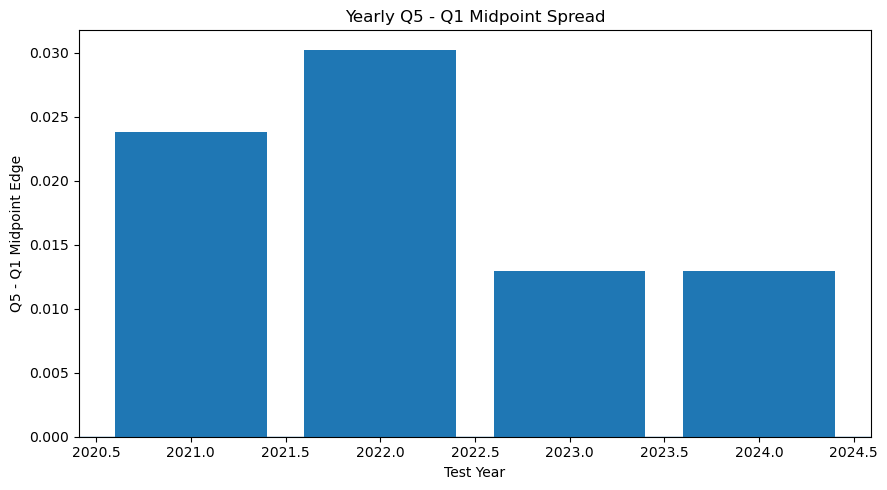

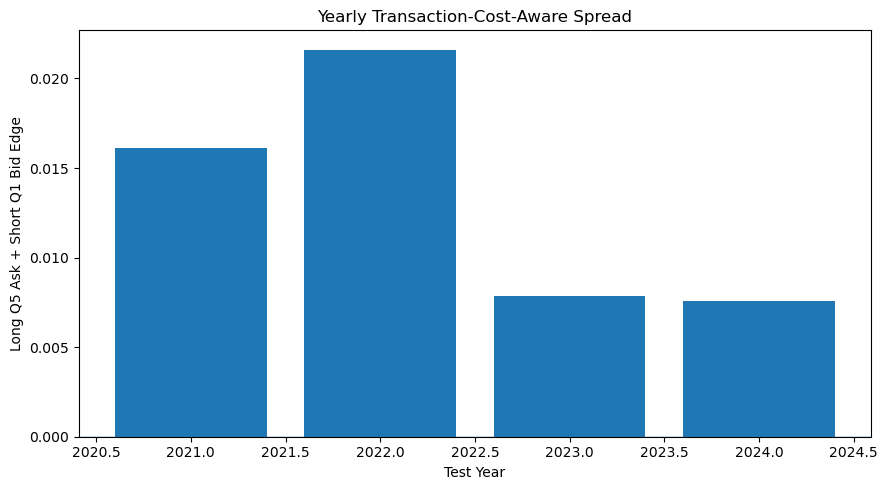

In [13]:
# Final chart 2:
# Year-by-year Q5-Q1 midpoint spread and bid/ask spread.
#
# This shows whether the result is stable across test years.

plt.figure(figsize=(9, 5))
plt.bar(primary_yearly["test_year"], primary_yearly["q5_minus_q1_mid_edge"])
plt.axhline(0, linewidth=1)
plt.xlabel("Test Year")
plt.ylabel("Q5 - Q1 Midpoint Edge")
plt.title("Yearly Q5 - Q1 Midpoint Spread")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))
plt.bar(primary_yearly["test_year"], primary_yearly["long_q5_ask_short_q1_bid_edge"])
plt.axhline(0, linewidth=1)
plt.xlabel("Test Year")
plt.ylabel("Long Q5 Ask + Short Q1 Bid Edge")
plt.title("Yearly Transaction-Cost-Aware Spread")
plt.tight_layout()
plt.show()

In [14]:
# Final chart 3:
# Show model coefficients if available.
#
# This helps explain what the model learned.

if len(coef_summary) > 0:
    coef_plot = coef_summary.copy()
    coef_plot = coef_plot.sort_values("avg_coefficient")
    
    plt.figure(figsize=(9, 5))
    plt.bar(coef_plot["feature"], coef_plot["avg_coefficient"])
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average Standardized Coefficient")
    plt.title("Ridge Regression Coefficient Summary")
    plt.tight_layout()
    plt.show()
else:
    print("Coefficient summary not available.")

Coefficient summary not available.


In [15]:
# Display headline summary in a clean readable format.

headline_display = headline_summary[
    ["result", "formatted_value", "interpretation"]
].copy()

display(headline_display)

,result,formatted_value,interpretation
0,Loose clean sample events,"9,022",Number of earnings events in the main clean da...
1,Loose clean sample tickers,474,Number of unique tickers in the main clean dat...
2,Average implied move,5.71%,Average move priced by the pre-earnings ATM st...
3,Average realized move,4.27%,Average actual post-earnings move
4,Average straddle edge,-1.44%,Realized move minus implied move; negative mea...
5,Buy all straddles midpoint edge,-1.36%,Average edge from buying all test-period strad...
6,Buy Q5 predicted-best midpoint edge,-0.48%,Average edge from buying only model's top quin...
7,Buy Q5 predicted-best ask edge,-0.60%,Average edge from buying model's top quintile ...
8,Q5 - Q1 midpoint spread,1.95%,Predicted-best minus predicted-worst midpoint ...
9,Q5 ask / Q1 bid spread,1.29%,Long top quintile at ask and short bottom quin...


In [16]:
# Write a final interpretation paragraph.
#
# This can be copied into a README, report, or interview notes.

final_interpretation = f"""
Final Project Interpretation

This project studies cross-sectional mispricing in earnings straddles.
Each earnings event is represented by the nearest post-earnings ATM straddle.
The implied move is measured as the straddle price divided by the stock price,
and the realized move is measured using the stock's post-earnings move.

The main clean dataset contains {int(loose_baseline['n_events']):,} earnings events
across {int(loose_baseline['n_tickers']):,} tickers from {loose_baseline['start_date']} to {loose_baseline['end_date']}.

The average implied move is {as_pct(loose_baseline['avg_implied_move'])},
while the average realized move is {as_pct(loose_baseline['avg_realized_move'])}.
This gives an average straddle edge of {as_pct(loose_baseline['avg_edge'])},
meaning earnings straddles are expensive on average.

The out-of-sample model ranks straddles by predicted edge.
Using the linear regression model, the predicted-best quintile has a midpoint edge of
{as_pct(model_row['buy_q5_mid_edge'])}, compared with {as_pct(model_row['buy_all_mid_edge'])}
for buying all straddles and {as_pct(model_row['buy_q1_mid_edge'])} for the predicted-worst quintile.

The predicted-best minus predicted-worst spread is {as_pct(model_row['q5_minus_q1_mid_edge'])}
using midpoint prices and {as_pct(model_row['long_q5_ask_short_q1_bid_edge'])}
using a simple bid/ask transaction-cost adjustment.

The top-decile minus bottom-decile spread is even stronger:
{as_pct(decile_row['d10_minus_d1_mid_edge'])} at midpoint and
{as_pct(decile_row['long_d10_ask_short_d1_bid_edge'])} using bid/ask assumptions.

Overall, the results suggest that earnings straddles are generally expensive,
but their relative overpricing is predictable cross-sectionally.
The model is most useful as a ranking and trade-filtering tool:
it helps avoid the most overpriced long-volatility trades and supports
a theoretical relative-value long-best / short-worst volatility spread.
It should not be interpreted as a guaranteed profitable long-only straddle strategy,
because even the predicted-best long straddles remain slightly negative after ask-cost assumptions.
"""

print(final_interpretation)

with open(final_project_summary_txt, "w", encoding="utf-8") as f:
    f.write(final_interpretation)

print("\nSaved final interpretation to:")
print(final_project_summary_txt)


Final Project Interpretation

This project studies cross-sectional mispricing in earnings straddles.
Each earnings event is represented by the nearest post-earnings ATM straddle.
The implied move is measured as the straddle price divided by the stock price,
and the realized move is measured using the stock's post-earnings move.

The main clean dataset contains 9,022 earnings events
across 474 tickers from 2018-02-08 00:00:00 to 2024-12-20 00:00:00.

The average implied move is 5.71%,
while the average realized move is 4.27%.
This gives an average straddle edge of -1.44%,
meaning earnings straddles are expensive on average.

The out-of-sample model ranks straddles by predicted edge.
Using the linear regression model, the predicted-best quintile has a midpoint edge of
-0.48%, compared with -1.36%
for buying all straddles and -2.43% for the predicted-worst quintile.

The predicted-best minus predicted-worst spread is 1.95%
using midpoint prices and 1.29%
using a simple bid/ask transactio

In [17]:
# Create polished resume bullets.
#
# These should be edited depending on how much space you have on your resume.

resume_bullets = f"""
Resume Bullet Options

Option 1 - Full technical bullet:
Developed an out-of-sample earnings straddle mispricing model using OptionMetrics and CRSP-linked data, ranking {int(model_row['n_total_events']):,}+ earnings events by predicted volatility edge across 2021–2024.

Option 2 - Results-focused bullet:
Built liquidity-aware ATM straddle filters and bid/ask transaction-cost checks; predicted-best quintile outperformed predicted-worst quintile by {as_pct(model_row['q5_minus_q1_mid_edge'])} at midpoint and {as_pct(model_row['long_q5_ask_short_q1_bid_edge'])} after simple bid/ask assumptions.

Option 3 - Signal interpretation bullet:
Found that high implied earnings moves and wider option spreads predict worse future straddle edge, while higher option volume improves relative straddle attractiveness.

Option 4 - Short one-line version:
Developed an earnings-volatility alpha model ranking ATM straddles by predicted mispricing; top predicted quintile outperformed bottom quintile by ~{100 * model_row['q5_minus_q1_mid_edge']:.1f} percentage points out of sample.

Option 5 - Conservative version:
Researched cross-sectional earnings straddle overpricing using OptionMetrics/CRSP data, showing that simple implied-move and liquidity signals improve long-volatility trade selection and identify overpriced straddles to avoid.
"""

print(resume_bullets)

with open(final_resume_bullets_txt, "w", encoding="utf-8") as f:
    f.write(resume_bullets)

print("\nSaved resume bullets to:")
print(final_resume_bullets_txt)


Resume Bullet Options

Option 1 - Full technical bullet:
Developed an out-of-sample earnings straddle mispricing model using OptionMetrics and CRSP-linked data, ranking 5,516+ earnings events by predicted volatility edge across 2021–2024.

Option 2 - Results-focused bullet:
Built liquidity-aware ATM straddle filters and bid/ask transaction-cost checks; predicted-best quintile outperformed predicted-worst quintile by 1.95% at midpoint and 1.29% after simple bid/ask assumptions.

Option 3 - Signal interpretation bullet:
Found that high implied earnings moves and wider option spreads predict worse future straddle edge, while higher option volume improves relative straddle attractiveness.

Option 4 - Short one-line version:
Developed an earnings-volatility alpha model ranking ATM straddles by predicted mispricing; top predicted quintile outperformed bottom quintile by ~2.0 percentage points out of sample.

Option 5 - Conservative version:
Researched cross-sectional earnings straddle overp

In [18]:
# Create a README-style summary.
#
# This can be used for GitHub or a project write-up.

readme_summary = f"""
# Earnings Straddle Mispricing: Cross-Sectional Alpha Study

## Research Question

Can pre-earnings option and liquidity features predict which earnings straddles are relatively overpriced or underpriced?

## Methodology

- Built a dataset of ATM earnings straddles using options expiring after earnings announcements.
- Measured implied move as ATM straddle price divided by stock price.
- Measured realized move using the post-earnings stock move.
- Defined straddle edge as realized move minus implied move.
- Used expanding-window out-of-sample tests from 2021–2024.
- Compared simple signals, linear regression, and ridge regression.
- Evaluated midpoint and bid/ask transaction-cost-aware results.

## Main Findings

- Average implied move: {as_pct(loose_baseline['avg_implied_move'])}
- Average realized move: {as_pct(loose_baseline['avg_realized_move'])}
- Average straddle edge: {as_pct(loose_baseline['avg_edge'])}

This suggests earnings straddles are expensive on average.

## Prediction Results

- Buy-all midpoint edge: {as_pct(model_row['buy_all_mid_edge'])}
- Predicted-best Q5 midpoint edge: {as_pct(model_row['buy_q5_mid_edge'])}
- Predicted-worst Q1 midpoint edge: {as_pct(model_row['buy_q1_mid_edge'])}
- Q5 - Q1 midpoint spread: {as_pct(model_row['q5_minus_q1_mid_edge'])}
- Q5 ask / Q1 bid transaction-cost-aware spread: {as_pct(model_row['long_q5_ask_short_q1_bid_edge'])}

## Interpretation

The model does not show that naive long earnings straddles are profitable.
Instead, it shows that relative overpricing is predictable.
The strongest use case is ranking and filtering:
avoid the most overpriced straddles and evaluate relative-value long-best / short-worst volatility spreads.

## Caveats

- Results use simplified move-based edge rather than full option PnL.
- Short straddles have tail risk and margin constraints.
- Bid/ask assumptions are simplified.
- Further work could add sector controls, market volatility, realized volatility, prior earnings surprise, and full delta-hedged option PnL.
"""

print(readme_summary)

readme_summary_file = os.path.join(PROCESSED_DIR, "final_readme_summary.md")

with open(readme_summary_file, "w", encoding="utf-8") as f:
    f.write(readme_summary)

print("\nSaved README summary to:")
print(readme_summary_file)


# Earnings Straddle Mispricing: Cross-Sectional Alpha Study

## Research Question

Can pre-earnings option and liquidity features predict which earnings straddles are relatively overpriced or underpriced?

## Methodology

- Built a dataset of ATM earnings straddles using options expiring after earnings announcements.
- Measured implied move as ATM straddle price divided by stock price.
- Measured realized move using the post-earnings stock move.
- Defined straddle edge as realized move minus implied move.
- Used expanding-window out-of-sample tests from 2021–2024.
- Compared simple signals, linear regression, and ridge regression.
- Evaluated midpoint and bid/ask transaction-cost-aware results.

## Main Findings

- Average implied move: 5.71%
- Average realized move: 4.27%
- Average straddle edge: -1.44%

This suggests earnings straddles are expensive on average.

## Prediction Results

- Buy-all midpoint edge: -1.36%
- Predicted-best Q5 midpoint edge: -0.48%
- Predicted-worst Q1 midp

In [19]:
# Write caveats and possible future improvements.
#
# This is useful because it shows research maturity.
# You are not overclaiming the result.

caveats_next_steps = """
Caveats and Next Steps

1. Full option PnL
The current analysis uses move-based edge, not full option payoff PnL.
A future extension should calculate actual straddle payoff at expiration or after earnings.

2. Short-volatility risk
The short Q1 results are only a simplified proxy.
Short straddles have tail risk, margin requirements, and gap risk.

3. Bid/ask assumptions
The bid/ask transaction-cost adjustment is conservative but still simplified.
Actual execution could depend on order size and market conditions.

4. Additional features
Potential future features include:
- recent realized volatility
- prior earnings move
- analyst forecast dispersion
- market volatility / VIX
- sector or industry controls
- market cap
- option skew
- term structure of implied volatility

5. More robust modeling
The current linear/ridge models are intentionally simple and explainable.
A future extension could test random forest or gradient boosting, but only with strict out-of-sample validation.

6. Portfolio construction
Future work could create volatility-neutral or sector-neutral portfolios,
and test whether the signal survives risk controls.
"""

print(caveats_next_steps)

caveats_file = os.path.join(PROCESSED_DIR, "final_caveats_and_next_steps.txt")

with open(caveats_file, "w", encoding="utf-8") as f:
    f.write(caveats_next_steps)

print("\nSaved caveats and next steps to:")
print(caveats_file)


Caveats and Next Steps

1. Full option PnL
The current analysis uses move-based edge, not full option payoff PnL.
A future extension should calculate actual straddle payoff at expiration or after earnings.

2. Short-volatility risk
The short Q1 results are only a simplified proxy.
Short straddles have tail risk, margin requirements, and gap risk.

3. Bid/ask assumptions
The bid/ask transaction-cost adjustment is conservative but still simplified.
Actual execution could depend on order size and market conditions.

4. Additional features
Potential future features include:
- recent realized volatility
- prior earnings move
- analyst forecast dispersion
- market volatility / VIX
- sector or industry controls
- market cap
- option skew
- term structure of implied volatility

5. More robust modeling
The current linear/ridge models are intentionally simple and explainable.
A future extension could test random forest or gradient boosting, but only with strict out-of-sample validation.

6. Por

In [20]:
# Final checklist to confirm the project is ready to present.

print("=" * 100)
print("FINAL PROJECT CHECKLIST")
print("=" * 100)

checklist = [
    ("Built clean earnings straddle dataset", True),
    ("Computed implied move and realized move", True),
    ("Created straddle edge target", True),
    ("Applied liquidity filters", True),
    ("Tested simple signals with quintiles", True),
    ("Built out-of-sample linear/ridge models", True),
    ("Compared against implied-move baseline", True),
    ("Evaluated midpoint and bid/ask transaction costs", True),
    ("Checked year-by-year stability", True),
    ("Created final summary tables", os.path.exists(final_summary_csv)),
    ("Created final resume bullets", os.path.exists(final_resume_bullets_txt)),
    ("Created README-style summary", os.path.exists(readme_summary_file)),
]

for item, status in checklist:
    print(f"{'DONE' if status else 'MISSING'} - {item}")

print("\nProject status:")
print("Core research pipeline is complete.")
print("Next step is to polish the explanation, charts, and resume bullets.")

FINAL PROJECT CHECKLIST
DONE - Built clean earnings straddle dataset
DONE - Computed implied move and realized move
DONE - Created straddle edge target
DONE - Applied liquidity filters
DONE - Tested simple signals with quintiles
DONE - Built out-of-sample linear/ridge models
DONE - Compared against implied-move baseline
DONE - Evaluated midpoint and bid/ask transaction costs
DONE - Checked year-by-year stability
DONE - Created final summary tables
DONE - Created final resume bullets
DONE - Created README-style summary

Project status:
Core research pipeline is complete.
Next step is to polish the explanation, charts, and resume bullets.
